# 📊 Day 20 — Decision Trees
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is a Decision Tree  
2️⃣ How It Works — Key Concepts  
3️⃣ Loading & Preparing the Data  
4️⃣ Decision Tree Classifier  
5️⃣ Visualizing the Tree  
6️⃣ Evaluating the Model  
7️⃣ Overfitting & Pruning  
8️⃣ Decision Tree Regressor  
9️⃣ Feature Importance  
🔟 When to Use What  

---
## 1️⃣ What is a Decision Tree?

A Decision Tree is a supervised ML algorithm that makes predictions by **asking a series of yes/no questions** about the features.

It works like a flowchart:
- Start at the root node
- At each node, ask a question about a feature
- Follow the branch based on the answer
- Reach a leaf node — that is the prediction

> **Key idea:** Decision Trees split data into groups at each node to make the groups as pure as possible.

---
## 2️⃣ How It Works — Key Concepts

| Term | Meaning |
|------|---------|
| Root Node | First split — the most important feature |
| Internal Node | A question about a feature |
| Branch | The outcome of a question (yes/no) |
| Leaf Node | Final prediction — no more splits |
| Depth | Number of levels in the tree |
| Gini Impurity | Measures how mixed a node is (0 = pure) |
| Information Gain | How much a split reduces impurity |
| Pruning | Cutting branches to prevent overfitting |

**The algorithm always picks the split that gives the highest Information Gain.**

---
## 3️⃣ Loading & Preparing the Data

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [4]:
# Keep relevant columns and drop missing values
df = df[['country', 'variety', 'points', 'price']].dropna()
print("Shape:", df.shape)

Shape: (120915, 4)


In [5]:
# Create target variable — classify wine as Premium (1) or Regular (0)
df['is_premium'] = (df['points'] >= 90).astype(int)

print("Premium wines:", df['is_premium'].sum())
print("Regular wines:", (df['is_premium'] == 0).sum())

Premium wines: 45373
Regular wines: 75542


In [6]:
# Encode categorical columns
le_country = LabelEncoder()
le_variety = LabelEncoder()

df['country_encoded'] = le_country.fit_transform(df['country'])
df['variety_encoded'] = le_variety.fit_transform(df['variety'])

df.head(3)

,country,variety,points,price,is_premium,country_encoded,variety_encoded
1,Portugal,Portuguese Red,87,15.0,0,30,442
2,US,Pinot Gris,87,14.0,0,39,428
3,US,Riesling,87,13.0,0,39,471


---
## 4️⃣ Decision Tree Classifier

Classification = predicting a category (Premium or Regular wine).

In [7]:
# Features and target
X = df[['price', 'country_encoded', 'variety_encoded']]
y = df['is_premium']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (96732, 3)
Test size: (24183, 3)


In [8]:
# Train Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

print("Model trained successfully!")
print("Tree Depth:", dt_clf.get_depth())
print("Number of Leaves:", dt_clf.get_n_leaves())

Model trained successfully!
Tree Depth: 28
Number of Leaves: 8285


---
## 5️⃣ Visualizing the Tree

One of the biggest advantages of Decision Trees — they are fully interpretable and visualizable.

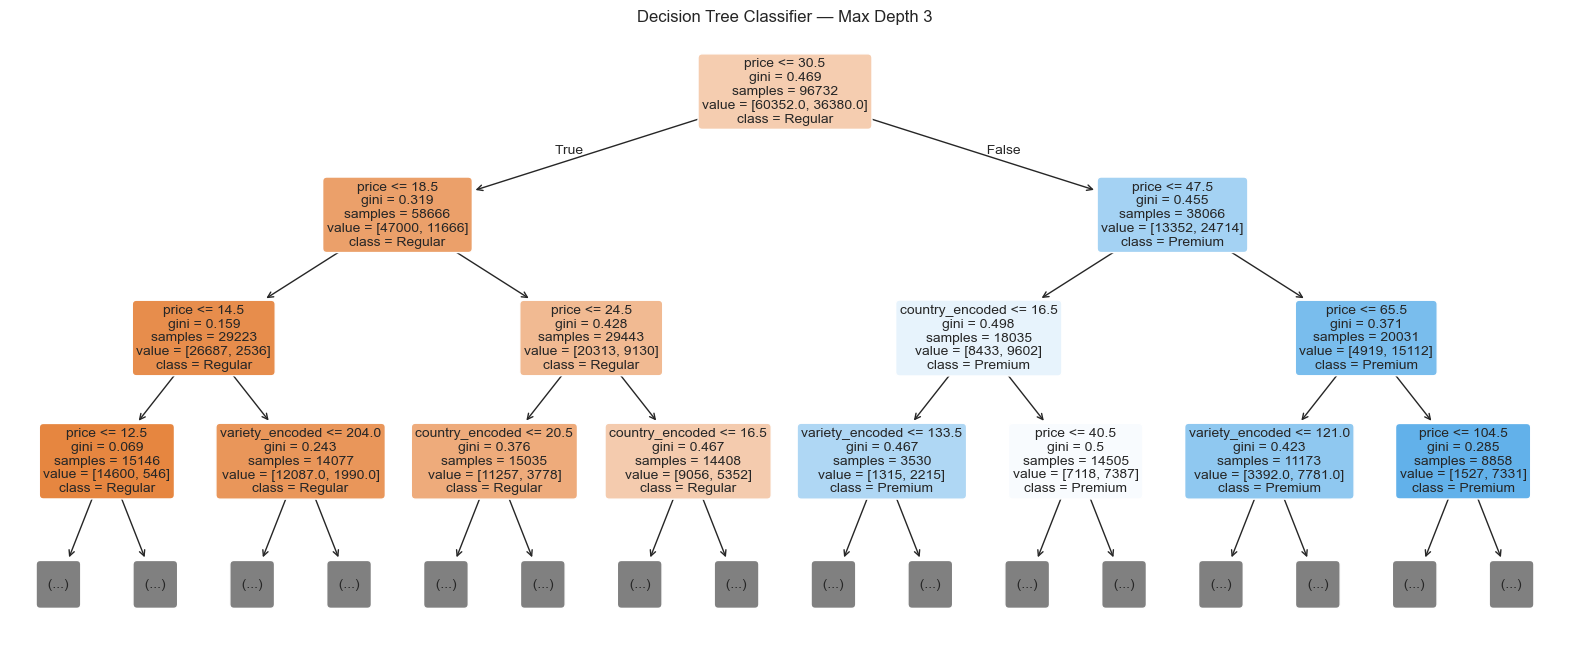

In [9]:
# Visualize the full tree — limited to depth 3 for readability
plt.figure(figsize=(20, 8))
plot_tree(
    dt_clf,
    max_depth=3,
    feature_names=['price', 'country_encoded', 'variety_encoded'],
    class_names=['Regular', 'Premium'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classifier — Max Depth 3")
plt.show()

In [10]:
# Print tree as text rules
tree_rules = export_text(dt_clf, feature_names=['price', 'country_encoded', 'variety_encoded'], max_depth=3)
print(tree_rules)

|--- price <= 30.50
|   |--- price <= 18.50
|   |   |--- price <= 14.50
|   |   |   |--- price <= 12.50
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- price >  12.50
|   |   |   |   |--- truncated branch of depth 20
|   |   |--- price >  14.50
|   |   |   |--- variety_encoded <= 204.00
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- variety_encoded >  204.00
|   |   |   |   |--- truncated branch of depth 23
|   |--- price >  18.50
|   |   |--- price <= 24.50
|   |   |   |--- country_encoded <= 20.50
|   |   |   |   |--- truncated branch of depth 23
|   |   |   |--- country_encoded >  20.50
|   |   |   |   |--- truncated branch of depth 22
|   |   |--- price >  24.50
|   |   |   |--- country_encoded <= 16.50
|   |   |   |   |--- truncated branch of depth 23
|   |   |   |--- country_encoded >  16.50
|   |   |   |   |--- truncated branch of depth 25
|--- price >  30.50
|   |--- price <= 47.50
|   |   |--- country_encoded <= 16.50
|   |   |   |--- var

---
## 6️⃣ Evaluating the Model

In [11]:
# Predictions
y_pred = dt_clf.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Accuracy: 75.54 %


In [12]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Regular', 'Premium']))

              precision    recall  f1-score   support

     Regular       0.79      0.84      0.81     15190
     Premium       0.69      0.61      0.65      8993

    accuracy                           0.76     24183
   macro avg       0.74      0.73      0.73     24183
weighted avg       0.75      0.76      0.75     24183



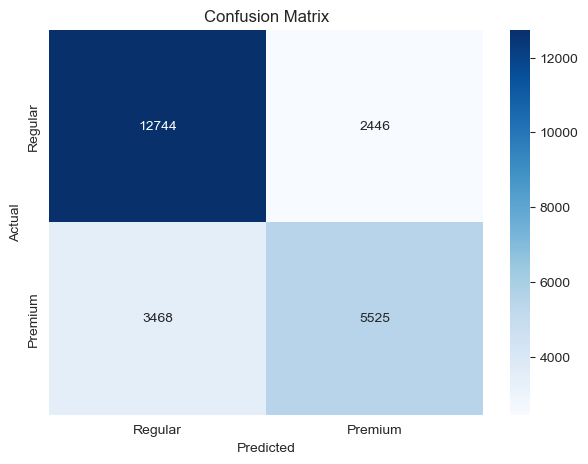

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Regular', 'Premium'],
            yticklabels=['Regular', 'Premium'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 💡 Reading the Confusion Matrix

| | Predicted Regular | Predicted Premium |
|--|--|--|
| **Actual Regular** | True Negative (TN) | False Positive (FP) |
| **Actual Premium** | False Negative (FN) | True Positive (TP) |

---
## 7️⃣ Overfitting & Pruning

An unpruned Decision Tree memorizes training data — it performs perfectly on train but poorly on test.

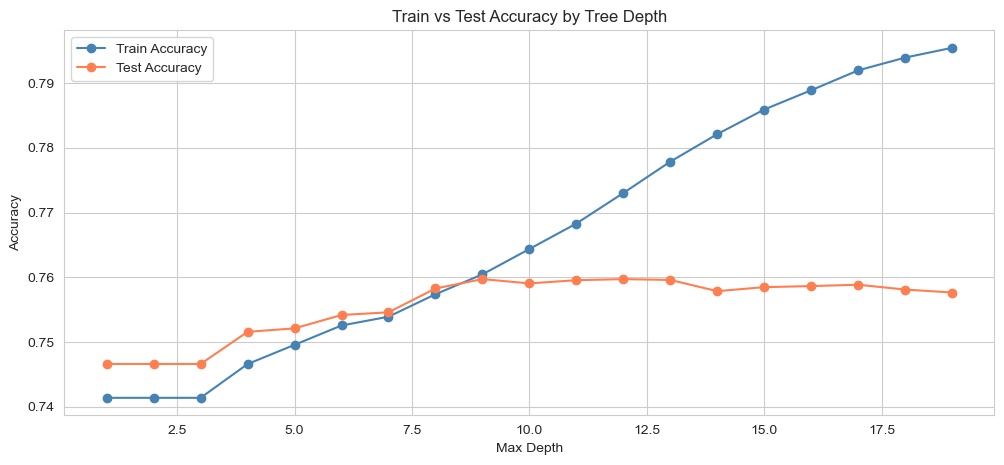

In [14]:
# Compare train vs test accuracy at different tree depths
depths = range(1, 20)
train_scores = []
test_scores  = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(12, 5))
plt.plot(depths, train_scores, label='Train Accuracy', color='steelblue', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', color='coral', marker='o')
plt.title("Train vs Test Accuracy by Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
# Train pruned tree with best depth
best_depth = test_scores.index(max(test_scores)) + 1
print("Best Depth:", best_depth)

dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
print("Pruned Tree Accuracy:", round(accuracy_score(y_test, y_pred_pruned) * 100, 2), "%")

Best Depth: 9
Pruned Tree Accuracy: 75.97 %


---
## 8️⃣ Decision Tree Regressor

Decision Trees can also predict numerical values — not just categories.

In [16]:
# Predict wine price using Decision Tree Regressor
X_reg = df[['points', 'country_encoded', 'variety_encoded']]
y_reg = df['price']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [17]:
# Train Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_r, y_train_r)

y_pred_r = dt_reg.predict(X_test_r)

print("Regressor Results:")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
print(f"R²   : {r2_score(y_test_r, y_pred_r):.4f}")

Regressor Results:
RMSE : 38.94
R²   : 0.2353


---
## 9️⃣ Feature Importance

Decision Trees tell you exactly which features matter most for predictions.

C:\Users\aslam\AppData\Local\Temp\ipykernel_9532\2835985251.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


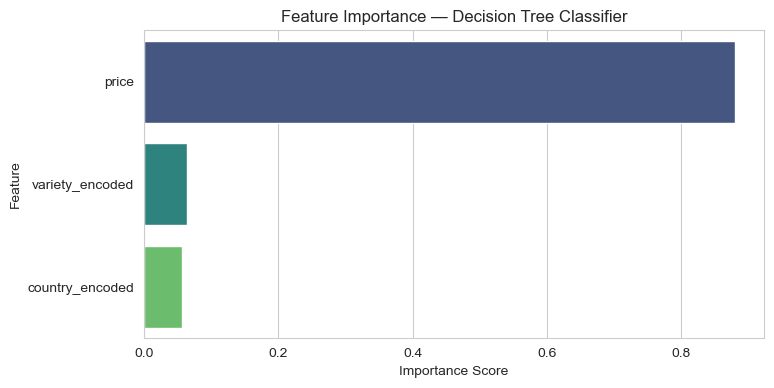

In [18]:
# Feature importance from pruned classifier
feature_names = ['price', 'country_encoded', 'variety_encoded']
importances   = dt_pruned.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance — Decision Tree Classifier")
plt.xlabel("Importance Score")
plt.show()

In [19]:
# Cross validation score of pruned tree
cv_scores = cross_val_score(dt_pruned, X, y, cv=5, scoring='accuracy')

print("Cross Validation Accuracy Scores:", cv_scores.round(4))
print("Mean Accuracy:", cv_scores.mean().round(4))
print("Std Dev:", cv_scores.std().round(4))

Cross Validation Accuracy Scores: [0.755  0.7625 0.748  0.7594 0.7605]
Mean Accuracy: 0.7571
Std Dev: 0.0051


---
## 🔟 When to Use What

| Situation | What to Do |
|-----------|------------|
| Predict a category | DecisionTreeClassifier |
| Predict a number | DecisionTreeRegressor |
| Tree is overfitting | Set `max_depth` to prune it |
| Find best depth | Plot train vs test accuracy curve |
| Want interpretability | Use `plot_tree` or `export_text` |
| Need feature importance | Use `.feature_importances_` |
| Need reliable score | Use `cross_val_score` with 5 folds |
| Need better accuracy | Use Random Forest (next step after Decision Trees) |

---
## 🔑 Key Takeaways

→ Decision Trees make predictions by asking yes/no questions about features  
→ They work for both classification and regression tasks  
→ An unpruned tree always overfits — always set `max_depth`  
→ Plot train vs test accuracy at different depths to find the best one  
→ Decision Trees are fully interpretable — you can read exactly why a prediction was made  
→ Feature importance tells you which features the tree relies on most  
→ Decision Trees are the foundation of Random Forest and Gradient Boosting — learn them well

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 20 of 100 — Keep Learning, Keep Building 🚀*